# Raytracing Server Demo

This notebook demonstrates how to use the raytracing server to calculate obstruction angles for a window based on surrounding 3D geometry.

In [21]:
import requests
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

## 1. Setup Server Connection

Make sure the server is running on `http://localhost:8081`

Start the server with:
```bash
python -m src.main
```

In [22]:
SERVER_URL = "http://localhost:8081"

# Check server status
response = requests.get(f"{SERVER_URL}/")
print("Server Status:", response.json())

Server Status: {'services': {'raytrace_service': {'obstruction_calculator': 'MaxHeightObstructionCalculator', 'projection_calculator': 'OrthographicProjectionCalculator', 'status': 'ready'}}, 'status': 'running'}


## 2. Define Scenario

We'll create a scenario with:
- A window at ground level (y=1.5m) at the origin, facing east (positive X direction)
- A building 10 meters away (x=10), extending 5 meters high and 10 meters wide

## Understanding the Coordinate System

**Coordinate System: XYZ (Right-Handed)**
- **X**: Horizontal axis (forward/backward)
- **Y**: Vertical axis (UP ⬆️) - Ground is at Y=0
- **Z**: Horizontal axis (left/right width)

**Window Normal Vector (rad_x, rad_y)**

The parameters `rad_x` and `rad_y` are **rotation angles in radians** that define the direction the window is facing:

- `rad_x`: Rotation around X-axis (pitch) - looking up (+) or down (-)
- `rad_y`: Rotation around Y-axis (yaw) - looking left (-) or right (+)

These angles are converted internally to a **unit vector** (magnitude = 1) using:
```python
normal_x = cos(rad_y) * cos(rad_x)
normal_y = sin(rad_x)
normal_z = sin(rad_y) * cos(rad_x)
```

**Examples:**
- `(rad_x=0, rad_y=0)` → Normal = (1, 0, 0) → Facing +X (forward)
- `(rad_x=π/2, rad_y=0)` → Normal = (0, 1, 0) → Facing +Y (up)
- `(rad_x=0, rad_y=π/2)` → Normal = (0, 0, 1) → Facing +Z (right)
- `(rad_x=0, rad_y=π)` → Normal = (-1, 0, 0) → Facing -X (backward)

In [32]:
# Window parameters
window_center = [0.0, 3, 0.0]  # At origin, 1.5m high (eye level)
window_normal_angles = [0.0, 0.8]  # Facing forward (positive X direction)

# Create a building 10m away, 5m tall, 10m wide
# The building is represented as multiple triangles forming a rectangular face
building_distance = 10.0  # meters away
building_height = 5.0     # meters tall
building_width = 10.0     # meters wide

# Create two triangles that form a rectangular facade
# Triangle 1: bottom-left, top-left, bottom-right
# Triangle 2: bottom-right, top-left, top-right
mesh = [
    # Triangle 1
    [building_distance, 0.0, -building_width/2],  # bottom-left
    [building_distance, building_height, -building_width/2],  # top-left
    [building_distance, 0.0, building_width/2],   # bottom-right
    
    # Triangle 2
    [building_distance, 0.0, building_width/2],   # bottom-right
    [building_distance, building_height, -building_width/2],  # top-left
    [building_distance, building_height, building_width/2]    # top-right
]

print(f"Window at: {window_center}")
print(f"Window facing: X direction (rad_x={window_normal_angles[0]}, rad_y={window_normal_angles[1]})")
print(f"Building: {building_distance}m away, {building_height}m tall, {building_width}m wide")
print(f"Mesh has {len(mesh)} vertices ({len(mesh)//3} triangles)")

Window at: [0.0, 3, 0.0]
Window facing: X direction (rad_x=0.0, rad_y=0.8)
Building: 10.0m away, 5.0m tall, 10.0m wide
Mesh has 6 vertices (2 triangles)


## 3. Call the Raytracing Server

In [33]:
# Prepare request payload
request_data = {
    "x": window_center[0],
    "y": window_center[1],
    "z": window_center[2],
    "rad_x": window_normal_angles[0],
    "rad_y": window_normal_angles[1],
    "mesh": mesh
}

# Make the request
response = requests.post(
    f"{SERVER_URL}/raytrace",
    json=request_data,
    headers={"Content-Type": "application/json"}
)

# Parse response
result = response.json()
print("Response Status:", response.status_code)
print("\nResult:")
print(result)

Response Status: 200

Result:
{'data': {'highest_point': {'x': 10.0, 'y': 5.0, 'z': -5.0}, 'obstruction_angle_degrees': 30.61135164537986, 'obstruction_angle_radians': 0.5342688746976622, 'projected_point_count': 6}, 'status': 'success'}


## 4. Extract and Display Results

In [34]:
if result.get("status") == "success":
    data = result["data"]
    
    obstruction_degrees = data["obstruction_angle_degrees"]
    obstruction_radians = data["obstruction_angle_radians"]
    highest_point = data["highest_point"]
    point_count = data["projected_point_count"]
    
    print(f"\n{'='*50}")
    print(f"OBSTRUCTION ANALYSIS RESULTS")
    print(f"{'='*50}")
    print(f"Obstruction Angle: {obstruction_degrees:.2f}° ({obstruction_radians:.4f} rad)")
    print(f"Highest Point: ({highest_point['x']:.2f}, {highest_point['y']:.2f}, {highest_point['z']:.2f})")
    print(f"Points Analyzed: {point_count}")
    print(f"{'='*50}\n")
    
    # Calculate expected angle manually for verification
    # From window at (0, 1.5, 0) to building top at (10, 5, 0)
    # Vertical distance: 5 - 1.5 = 3.5m
    # Horizontal distance: 10m
    # Expected angle: arctan(3.5/10) ≈ 19.29°
    expected_angle = np.degrees(np.arctan((building_height - window_center[1]) / building_distance))
    print(f"Expected angle (manual calculation): {expected_angle:.2f}°")
    print(f"Difference: {abs(obstruction_degrees - expected_angle):.4f}°")
else:
    print("ERROR:", result.get("error"))


OBSTRUCTION ANALYSIS RESULTS
Obstruction Angle: 30.61° (0.5343 rad)
Highest Point: (10.00, 5.00, -5.00)
Points Analyzed: 6

Expected angle (manual calculation): 11.31°
Difference: 19.3014°


## 5. Visualize the Scene in 3D

This visualization shows:
- The window center point (red)
- The 3D geometry/building (blue)
- The projection plane (semi-transparent green)
- The obstruction vector from window to highest point (orange arrow)

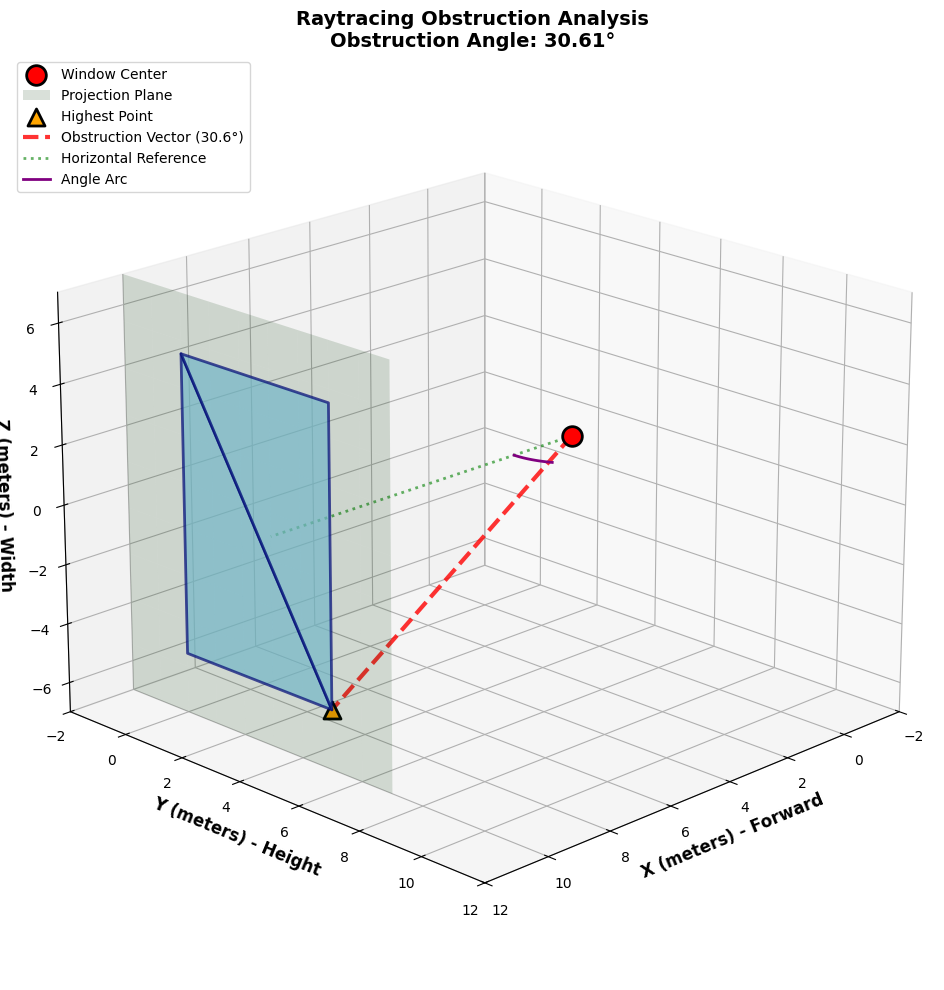

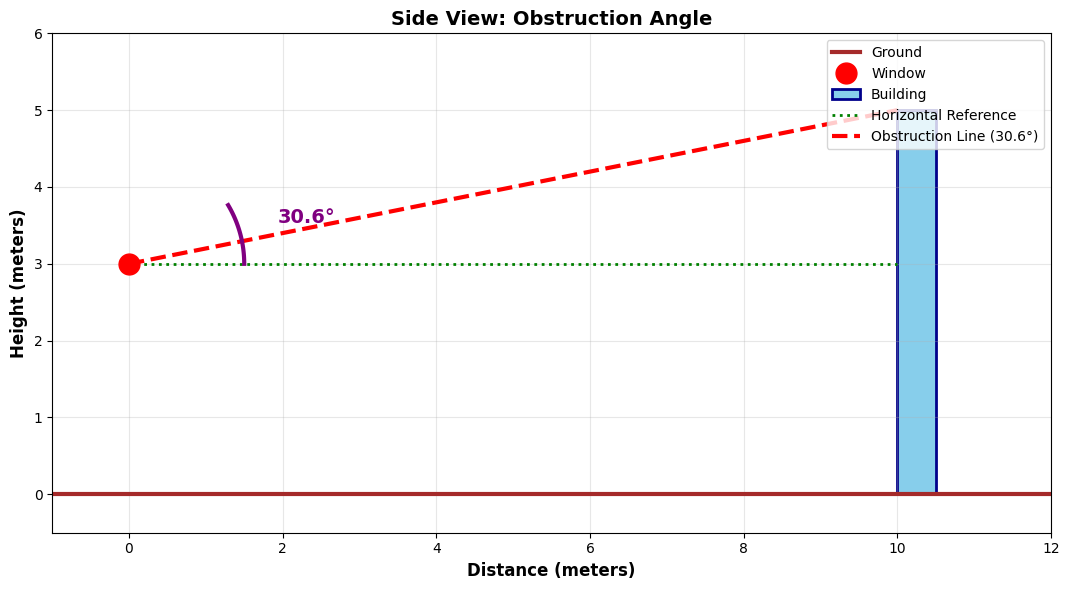

In [35]:
if result.get("status") == "success":
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. Plot window center point
    ax.scatter(
        window_center[0], 
        window_center[1], 
        window_center[2],
        color='red', 
        s=200, 
        marker='o',
        label='Window Center',
        edgecolors='black',
        linewidths=2
    )
    
    # 2. Plot the building mesh (triangles)
    triangles = []
    for i in range(0, len(mesh), 3):
        triangle = [mesh[i], mesh[i+1], mesh[i+2]]
        triangles.append(triangle)
    
    mesh_collection = Poly3DCollection(
        triangles, 
        alpha=0.7, 
        facecolor='skyblue',
        edgecolor='darkblue',
        linewidths=2
    )
    ax.add_collection3d(mesh_collection)
    
    # 3. Plot the projection plane (vertical plane perpendicular to viewing direction)
    # Since we're looking in +X direction, the plane is at x=building_distance
    plane_x = building_distance
    plane_y = np.linspace(-2, building_height + 2, 10)
    plane_z = np.linspace(-building_width/2 - 2, building_width/2 + 2, 10)
    plane_Y, plane_Z = np.meshgrid(plane_y, plane_z)
    plane_X = np.ones_like(plane_Y) * plane_x
    
    ax.plot_surface(
        plane_X, 
        plane_Y, 
        plane_Z, 
        alpha=0.15, 
        color='green',
        label='Projection Plane'
    )
    
    # 4. Plot the highest point
    hp = highest_point
    ax.scatter(
        hp['x'], 
        hp['y'], 
        hp['z'],
        color='orange', 
        s=150, 
        marker='^',
        label='Highest Point',
        edgecolors='black',
        linewidths=2
    )
    
    # 5. Draw obstruction vector (from window to highest point)
    ax.plot(
        [window_center[0], hp['x']], 
        [window_center[1], hp['y']], 
        [window_center[2], hp['z']],
        'r--', 
        linewidth=3,
        label=f'Obstruction Vector ({obstruction_degrees:.1f}°)',
        alpha=0.8
    )
    
    # 6. Draw horizontal reference line (from window in viewing direction)
    ax.plot(
        [window_center[0], building_distance], 
        [window_center[1], window_center[1]], 
        [window_center[2], window_center[2]],
        'g:', 
        linewidth=2,
        label='Horizontal Reference',
        alpha=0.6
    )
    
    # 7. Draw the angle arc (visual representation)
    # Create an arc showing the obstruction angle
    arc_radius = 2.0
    angles_for_arc = np.linspace(0, obstruction_radians, 20)
    arc_x = window_center[0] + arc_radius * np.cos(angles_for_arc)
    arc_y = window_center[1] + arc_radius * np.sin(angles_for_arc)
    arc_z = np.zeros_like(arc_x) + window_center[2]
    ax.plot(arc_x, arc_y, arc_z, 'purple', linewidth=2, label=f'Angle Arc')
    
    # Labels and formatting
    ax.set_xlabel('X (meters) - Forward', fontsize=12, fontweight='bold')
    ax.set_ylabel('Y (meters) - Height', fontsize=12, fontweight='bold')
    ax.set_zlabel('Z (meters) - Width', fontsize=12, fontweight='bold')
    ax.set_title(
        f'Raytracing Obstruction Analysis\nObstruction Angle: {obstruction_degrees:.2f}°',
        fontsize=14,
        fontweight='bold'
    )
    
    # Set equal aspect ratio
    max_range = max(
        building_distance,
        building_height,
        building_width
    )
    ax.set_xlim(-2, max_range + 2)
    ax.set_ylim(-2, max_range + 2)
    ax.set_zlim(-max_range/2 - 2, max_range/2 + 2)
    
    # Add legend
    ax.legend(loc='upper left', fontsize=10)
    
    # Add grid
    ax.grid(True, alpha=0.3)
    
    # Set viewing angle
    ax.view_init(elev=20, azim=45)
    
    plt.tight_layout()
    plt.show()
    
    # Create a 2D side view showing the angle more clearly
    fig2, ax2 = plt.subplots(figsize=(12, 6))
    
    # Draw ground
    ax2.axhline(y=0, color='brown', linewidth=3, label='Ground')
    
    # Draw window
    ax2.plot(window_center[0], window_center[1], 'ro', markersize=15, label='Window', zorder=5)
    
    # Draw building
    building_rect = plt.Rectangle(
        (building_distance, 0), 
        0.5,  # thickness
        building_height,
        facecolor='skyblue',
        edgecolor='darkblue',
        linewidth=2,
        label='Building'
    )
    ax2.add_patch(building_rect)
    
    # Draw horizontal line
    ax2.plot(
        [window_center[0], building_distance], 
        [window_center[1], window_center[1]],
        'g:', 
        linewidth=2,
        label='Horizontal Reference'
    )
    
    # Draw obstruction line
    ax2.plot(
        [window_center[0], hp['x']], 
        [window_center[1], hp['y']],
        'r--', 
        linewidth=3,
        label=f'Obstruction Line ({obstruction_degrees:.1f}°)'
    )
    
    # Draw angle arc in 2D
    arc_radius_2d = 1.5
    angles_2d = np.linspace(0, obstruction_radians, 50)
    arc_x_2d = window_center[0] + arc_radius_2d * np.cos(angles_2d)
    arc_y_2d = window_center[1] + arc_radius_2d * np.sin(angles_2d)
    ax2.plot(arc_x_2d, arc_y_2d, 'purple', linewidth=3)
    
    # Add angle text
    mid_angle = obstruction_radians / 2
    text_x = window_center[0] + (arc_radius_2d + 0.5) * np.cos(mid_angle)
    text_y = window_center[1] + (arc_radius_2d + 0.5) * np.sin(mid_angle)
    ax2.text(
        text_x, text_y, 
        f'{obstruction_degrees:.1f}°',
        fontsize=14,
        fontweight='bold',
        color='purple'
    )
    
    ax2.set_xlabel('Distance (meters)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Height (meters)', fontsize=12, fontweight='bold')
    ax2.set_title('Side View: Obstruction Angle', fontsize=14, fontweight='bold')
    ax2.set_xlim(-1, building_distance + 2)
    ax2.set_ylim(-0.5, building_height + 1)
    ax2.set_aspect('equal')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize - request failed")

## 6. Try Different Scenarios

Experiment with different building heights and distances to see how the obstruction angle changes.

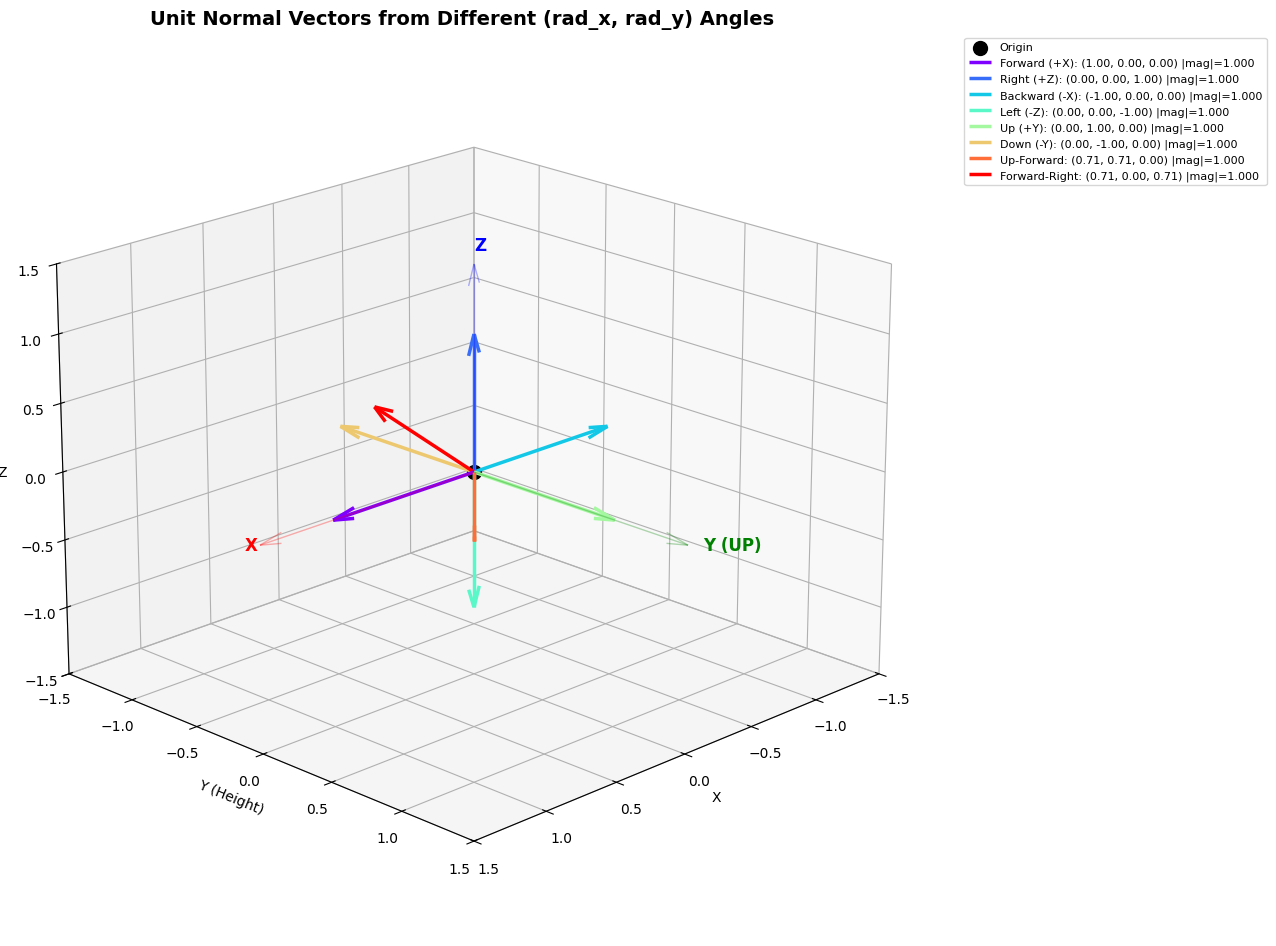


All vectors have magnitude ≈ 1.0 (unit vectors)

Notice how:
  • rad_x controls pitch (up/down rotation)
  • rad_y controls yaw (left/right rotation)
  • The resulting vector is always a unit vector on the unit sphere


In [27]:
# Function to convert angles to unit vector (same as in Vector3D.from_angles)
def angles_to_unit_vector(rad_x, rad_y):
    """Convert rotation angles to unit normal vector"""
    x = np.cos(rad_y) * np.cos(rad_x)
    y = np.sin(rad_x)
    z = np.sin(rad_y) * np.cos(rad_x)
    return np.array([x, y, z])

# Test different angle combinations
angle_combinations = [
    (0, 0, "Forward (+X)"),
    (0, np.pi/2, "Right (+Z)"),
    (0, np.pi, "Backward (-X)"),
    (0, -np.pi/2, "Left (-Z)"),
    (np.pi/2, 0, "Up (+Y)"),
    (-np.pi/2, 0, "Down (-Y)"),
    (np.pi/4, 0, "Up-Forward"),
    (0, np.pi/4, "Forward-Right"),
]

# Create 3D visualization
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot origin
ax.scatter([0], [0], [0], color='black', s=100, marker='o', label='Origin')

# Plot each normal vector
colors = plt.cm.rainbow(np.linspace(0, 1, len(angle_combinations)))

for (rad_x, rad_y, label), color in zip(angle_combinations, colors):
    vec = angles_to_unit_vector(rad_x, rad_y)
    magnitude = np.linalg.norm(vec)
    
    # Draw arrow
    ax.quiver(
        0, 0, 0,  # start point
        vec[0], vec[1], vec[2],  # direction
        color=color,
        arrow_length_ratio=0.15,
        linewidth=2.5,
        label=f"{label}: ({vec[0]:.2f}, {vec[1]:.2f}, {vec[2]:.2f}) |mag|={magnitude:.3f}"
    )

# Draw coordinate axes
axis_length = 1.5
ax.quiver(0, 0, 0, axis_length, 0, 0, color='red', arrow_length_ratio=0.1, linewidth=1, alpha=0.3)
ax.quiver(0, 0, 0, 0, axis_length, 0, color='green', arrow_length_ratio=0.1, linewidth=1, alpha=0.3)
ax.quiver(0, 0, 0, 0, 0, axis_length, color='blue', arrow_length_ratio=0.1, linewidth=1, alpha=0.3)

ax.text(axis_length + 0.1, 0, 0, 'X', color='red', fontsize=12, fontweight='bold')
ax.text(0, axis_length + 0.1, 0, 'Y (UP)', color='green', fontsize=12, fontweight='bold')
ax.text(0, 0, axis_length + 0.1, 'Z', color='blue', fontsize=12, fontweight='bold')

ax.set_xlabel('X')
ax.set_ylabel('Y (Height)')
ax.set_zlabel('Z')
ax.set_title('Unit Normal Vectors from Different (rad_x, rad_y) Angles', fontsize=14, fontweight='bold')
ax.legend(loc='upper left', fontsize=8, bbox_to_anchor=(1.05, 1))

# Set equal aspect ratio
ax.set_xlim(-1.5, 1.5)
ax.set_ylim(-1.5, 1.5)
ax.set_zlim(-1.5, 1.5)

ax.view_init(elev=20, azim=45)
plt.tight_layout()
plt.show()

print("\nAll vectors have magnitude ≈ 1.0 (unit vectors)")
print("\nNotice how:")
print("  • rad_x controls pitch (up/down rotation)")
print("  • rad_y controls yaw (left/right rotation)")
print("  • The resulting vector is always a unit vector on the unit sphere")

## 7. Visualize Normal Vector Directions

Let's visualize how different (rad_x, rad_y) angles create different unit normal vectors.

In [28]:
# Test multiple scenarios
scenarios = [
    {"distance": 5, "height": 5, "width": 10},
    {"distance": 10, "height": 10, "width": 10},
    {"distance": 20, "height": 5, "width": 10},
    {"distance": 10, "height": 2, "width": 10},
]

print(f"{'Distance (m)':<15} {'Height (m)':<15} {'Angle (°)':<15} {'Expected (°)':<15}")
print("=" * 60)

for scenario in scenarios:
    dist = scenario["distance"]
    height = scenario["height"]
    width = scenario["width"]
    
    mesh_temp = [
        [dist, 0.0, -width/2], [dist, height, -width/2], [dist, 0.0, width/2],
        [dist, 0.0, width/2], [dist, height, -width/2], [dist, height, width/2]
    ]
    
    request_temp = {
        "x": 0.0, "y": 1.5, "z": 0.0,
        "rad_x": 0.0, "rad_y": 0.0,
        "mesh": mesh_temp
    }
    
    response = requests.post(f"{SERVER_URL}/raytrace", json=request_temp)
    result_temp = response.json()
    
    if result_temp.get("status") == "success":
        angle = result_temp["data"]["obstruction_angle_degrees"]
        expected = np.degrees(np.arctan((height - 1.5) / dist))
        print(f"{dist:<15} {height:<15} {angle:<15.2f} {expected:<15.2f}")
    else:
        print(f"{dist:<15} {height:<15} ERROR")

Distance (m)    Height (m)      Angle (°)       Expected (°)   
5               5               34.99           34.99          
10              10              40.36           40.36          
20              5               9.93            9.93           
10              2               2.86            2.86           
